Heart disease is one of the leading causes of death worldwide, making early prediction and diagnosis extremely important. This project focuses on building a Machine Learning model to predict the likelihood of heart attacks based on various health-related factors such as age, hypertension, diabetes, cholesterol level, obesity, smoking status, and previous heart disease history.

The main objective of this project is to analyze medical data, identify important risk factors, and develop a predictive model that can assist in early detection of heart attack risk. In this project, several stages of the Machine Learning workflow were performed, including data preprocessing, exploratory data analysis (EDA), feature selection, model training, and performance evaluation.

Different classification algorithms such as Logistic Regression and Naive Bayes were explored to achieve accurate predictions. The project also includes visualization techniques to better understand the relationships between health conditions and heart attack occurrence.


In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [106]:
data = pd.read_csv('heart_attack_prediction.csv')
data.head()

,age,gender,region,income_level,hypertension,diabetes,cholesterol_level,obesity,waist_circumference,family_history,...,blood_pressure_diastolic,fasting_blood_sugar,cholesterol_hdl,cholesterol_ldl,triglycerides,EKG_results,previous_heart_disease,medication_usage,participated_in_free_screening,heart_attack
0,60,Male,Rural,Middle,0,1,211,0,83,0,...,62,173,48,121,101,Normal,0,0,0,0
1,53,Female,Urban,Low,0,0,208,0,106,1,...,76,70,58,83,138,Normal,1,0,1,0
2,62,Female,Urban,Low,0,0,231,1,112,1,...,74,118,69,130,171,Abnormal,0,1,0,1
3,73,Male,Urban,Low,1,0,202,0,82,1,...,65,98,52,85,146,Normal,0,1,1,0
4,52,Male,Urban,Middle,1,0,232,0,89,0,...,75,104,59,127,139,Normal,1,0,1,1


In [107]:
data.tail()

,age,gender,region,income_level,hypertension,diabetes,cholesterol_level,obesity,waist_circumference,family_history,...,blood_pressure_diastolic,fasting_blood_sugar,cholesterol_hdl,cholesterol_ldl,triglycerides,EKG_results,previous_heart_disease,medication_usage,participated_in_free_screening,heart_attack
158350,60,Female,Rural,Middle,0,0,199,0,79,0,...,74,79,52,238,234,Normal,0,1,0,0
158351,64,Female,Urban,Low,0,0,179,0,93,0,...,73,111,41,177,239,Normal,0,1,1,1
158352,30,Male,Urban,Middle,0,0,220,0,78,0,...,87,127,50,158,201,Abnormal,1,1,1,1
158353,74,Male,Urban,Middle,0,0,180,0,58,1,...,70,119,52,153,171,Normal,1,0,1,1
158354,61,Male,Urban,Middle,0,0,190,0,81,0,...,81,95,49,125,149,Abnormal,0,0,1,0


In [108]:
data.shape

(158355, 28)

In [109]:
data.columns

Index(['age', 'gender', 'region', 'income_level', 'hypertension', 'diabetes',
       'cholesterol_level', 'obesity', 'waist_circumference', 'family_history',
       'smoking_status', 'alcohol_consumption', 'physical_activity',
       'dietary_habits', 'air_pollution_exposure', 'stress_level',
       'sleep_hours', 'blood_pressure_systolic', 'blood_pressure_diastolic',
       'fasting_blood_sugar', 'cholesterol_hdl', 'cholesterol_ldl',
       'triglycerides', 'EKG_results', 'previous_heart_disease',
       'medication_usage', 'participated_in_free_screening', 'heart_attack'],
      dtype='str')

In [110]:
data.dtypes

age                                 int64
gender                                str
region                                str
income_level                          str
hypertension                        int64
diabetes                            int64
cholesterol_level                   int64
obesity                             int64
waist_circumference                 int64
family_history                      int64
smoking_status                        str
alcohol_consumption                   str
physical_activity                     str
dietary_habits                        str
air_pollution_exposure                str
stress_level                          str
sleep_hours                       float64
blood_pressure_systolic             int64
blood_pressure_diastolic            int64
fasting_blood_sugar                 int64
cholesterol_hdl                     int64
cholesterol_ldl                     int64
triglycerides                       int64
EKG_results                       

In [111]:
data.describe()

,age,hypertension,diabetes,cholesterol_level,obesity,waist_circumference,family_history,sleep_hours,blood_pressure_systolic,blood_pressure_diastolic,fasting_blood_sugar,cholesterol_hdl,cholesterol_ldl,triglycerides,previous_heart_disease,medication_usage,participated_in_free_screening,heart_attack
count,158355.000000,158355.000000,158355.000000,158355.000000,158355.000000,158355.000000,158355.000000,158355.000000,158355.000000,158355.000000,158355.000000,158355.000000,158355.000000,158355.000000,158355.000000,158355.000000,158355.000000,158355.000000
mean,54.543778,0.299069,0.199804,199.533264,0.249901,93.268504,0.300218,6.480064,129.515772,79.490809,110.736762,49.491478,129.569916,149.715885,0.200575,0.499770,0.601029,0.401004
std,11.910897,0.457851,0.399854,39.737565,0.432957,16.382205,0.458354,1.425398,15.005641,10.002964,27.673445,9.982634,34.913318,49.023473,0.400432,0.500002,0.489688,0.490103
min,25.000000,0.000000,0.000000,100.000000,0.000000,20.000000,0.000000,3.000000,61.000000,37.000000,70.000000,8.000000,-19.000000,50.000000,0.000000,0.000000,0.000000,0.000000
25%,46.000000,0.000000,0.000000,172.000000,0.000000,82.000000,0.000000,5.492985,119.000000,73.000000,89.000000,43.000000,106.000000,116.000000,0.000000,0.000000,0.000000,0.000000
50%,55.000000,0.000000,0.000000,199.000000,0.000000,93.000000,0.000000,6.507461,130.000000,80.000000,109.000000,49.000000,130.000000,149.000000,0.000000,0.000000,1.000000,0.000000
75%,63.000000,1.000000,0.000000,226.000000,0.000000,104.000000,1.000000,7.520640,140.000000,86.000000,130.000000,56.000000,153.000000,183.000000,0.000000,1.000000,1.000000,1.000000
max,90.000000,1.000000,1.000000,350.000000,1.000000,173.000000,1.000000,9.000000,199.000000,127.000000,230.000000,93.000000,282.000000,380.000000,1.000000,1.000000,1.000000,1.000000


In [112]:
data.duplicated().sum()

np.int64(0)

In [113]:
data.isna().mean()*100

age                                0.000000
gender                             0.000000
region                             0.000000
income_level                       0.000000
hypertension                       0.000000
diabetes                           0.000000
cholesterol_level                  0.000000
obesity                            0.000000
waist_circumference                0.000000
family_history                     0.000000
smoking_status                     0.000000
alcohol_consumption               59.895804
physical_activity                  0.000000
dietary_habits                     0.000000
air_pollution_exposure             0.000000
stress_level                       0.000000
sleep_hours                        0.000000
blood_pressure_systolic            0.000000
blood_pressure_diastolic           0.000000
fasting_blood_sugar                0.000000
cholesterol_hdl                    0.000000
cholesterol_ldl                    0.000000
triglycerides                   

In [114]:
data = data.drop(['alcohol_consumption'],axis=1)

In [115]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 158355 entries, 0 to 158354
Data columns (total 27 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   age                             158355 non-null  int64  
 1   gender                          158355 non-null  str    
 2   region                          158355 non-null  str    
 3   income_level                    158355 non-null  str    
 4   hypertension                    158355 non-null  int64  
 5   diabetes                        158355 non-null  int64  
 6   cholesterol_level               158355 non-null  int64  
 7   obesity                         158355 non-null  int64  
 8   waist_circumference             158355 non-null  int64  
 9   family_history                  158355 non-null  int64  
 10  smoking_status                  158355 non-null  str    
 11  physical_activity               158355 non-null  str    
 12  dietary_habits             

In [116]:
for i in data.select_dtypes(include=str):
    print(i)

gender
region
income_level
smoking_status
physical_activity
dietary_habits
air_pollution_exposure
stress_level
EKG_results


In [117]:
data['gender'].unique()

<ArrowStringArray>
['Male', 'Female']
Length: 2, dtype: str

In [118]:
data['gender'] = data['gender'].replace(['Male', 'Female'],[1,0])
data['gender'] = data['gender'].astype(float)
data['gender'].value_counts()

gender
1.0    82243
0.0    76112
Name: count, dtype: int64

In [119]:
data['region'].unique()

<ArrowStringArray>
['Rural', 'Urban']
Length: 2, dtype: str

In [120]:
data['region'] = data['region'].replace(['Rural', 'Urban'],[0,1])
data['region'] = data['region'].astype(float)
data['region'].value_counts()

region
1.0    103038
0.0     55317
Name: count, dtype: int64

In [121]:
data['income_level'].unique()

<ArrowStringArray>
['Middle', 'Low', 'High']
Length: 3, dtype: str

In [122]:
data['income_level'] = data['income_level'].replace(['Middle', 'Low', 'High'],[1,0,2])
data['income_level'] = data['income_level'].astype(float)
data['income_level'].value_counts()

income_level
1.0    71230
0.0    63422
2.0    23703
Name: count, dtype: int64

In [123]:
data['income_level'].value_counts()

income_level
1.0    71230
0.0    63422
2.0    23703
Name: count, dtype: int64

In [124]:
data['smoking_status'].unique()


<ArrowStringArray>
['Never', 'Past', 'Current']
Length: 3, dtype: str

In [125]:
from sklearn.preprocessing import OneHotEncoder
ohe_smoking = OneHotEncoder(sparse_output=False)
df1 = ohe_smoking.fit_transform(data[['smoking_status']])
df1 = pd.DataFrame(df1,columns= ohe_smoking.get_feature_names_out())
df1

,smoking_status_Current,smoking_status_Never,smoking_status_Past
0,0.0,1.0,0.0
1,0.0,0.0,1.0
2,0.0,0.0,1.0
3,0.0,1.0,0.0
4,1.0,0.0,0.0
...,...,...,...
158350,0.0,1.0,0.0
158351,0.0,1.0,0.0
158352,0.0,0.0,1.0
158353,0.0,0.0,1.0


In [126]:
data = pd.concat((data,df1),axis = 1)
data.head()

,age,gender,region,income_level,hypertension,diabetes,cholesterol_level,obesity,waist_circumference,family_history,...,cholesterol_ldl,triglycerides,EKG_results,previous_heart_disease,medication_usage,participated_in_free_screening,heart_attack,smoking_status_Current,smoking_status_Never,smoking_status_Past
0,60,1.0,0.0,1.0,0,1,211,0,83,0,...,121,101,Normal,0,0,0,0,0.0,1.0,0.0
1,53,0.0,1.0,0.0,0,0,208,0,106,1,...,83,138,Normal,1,0,1,0,0.0,0.0,1.0
2,62,0.0,1.0,0.0,0,0,231,1,112,1,...,130,171,Abnormal,0,1,0,1,0.0,0.0,1.0
3,73,1.0,1.0,0.0,1,0,202,0,82,1,...,85,146,Normal,0,1,1,0,0.0,1.0,0.0
4,52,1.0,1.0,1.0,1,0,232,0,89,0,...,127,139,Normal,1,0,1,1,1.0,0.0,0.0


In [127]:
data = data.drop('smoking_status',axis=1)

In [128]:
data['physical_activity'].unique()

<ArrowStringArray>
['High', 'Moderate', 'Low']
Length: 3, dtype: str

In [129]:
data['physical_activity'] = data['physical_activity'].replace(['High', 'Moderate', 'Low'],[2,1,0])
data['physical_activity'] = data['physical_activity'].astype(float)
data['physical_activity'].value_counts()

physical_activity
0.0    63417
1.0    63027
2.0    31911
Name: count, dtype: int64

In [130]:
data['dietary_habits'].unique()

<ArrowStringArray>
['Unhealthy', 'Healthy']
Length: 2, dtype: str

In [131]:
data['dietary_habits'] = data['dietary_habits'].replace(['Unhealthy', 'Healthy'],[0,1])
data['dietary_habits'] = data['dietary_habits'].astype(float)
data['dietary_habits'].value_counts()

dietary_habits
0.0    95030
1.0    63325
Name: count, dtype: int64

In [132]:
data['air_pollution_exposure'].unique()

<ArrowStringArray>
['Moderate', 'High', 'Low']
Length: 3, dtype: str

In [133]:
data['air_pollution_exposure'] = data['air_pollution_exposure'].replace(['Moderate', 'High', 'Low'],[1,2,0])
data['air_pollution_exposure'] = data['air_pollution_exposure'].astype(float)
data['air_pollution_exposure'].value_counts()

air_pollution_exposure
1.0    79144
0.0    47355
2.0    31856
Name: count, dtype: int64

In [134]:
data['stress_level'].unique()

<ArrowStringArray>
['Moderate', 'High', 'Low']
Length: 3, dtype: str

In [135]:
data['stress_level'] = data['stress_level'].replace(['Moderate', 'High', 'Low'],[1,2,0])
data['stress_level'] = data['stress_level'].astype(float)
data['stress_level'].value_counts()

stress_level
1.0    79366
2.0    47359
0.0    31630
Name: count, dtype: int64

In [136]:
data['EKG_results'].unique()

<ArrowStringArray>
['Normal', 'Abnormal']
Length: 2, dtype: str

In [137]:
data['EKG_results'] = data['EKG_results'].replace(['Normal', 'Abnormal'],[1,0])
data['EKG_results'] = data['EKG_results'].astype(float)
data['EKG_results'].value_counts()

EKG_results
1.0    126914
0.0     31441
Name: count, dtype: int64

In [138]:
data.info()


<class 'pandas.DataFrame'>
RangeIndex: 158355 entries, 0 to 158354
Data columns (total 29 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   age                             158355 non-null  int64  
 1   gender                          158355 non-null  float64
 2   region                          158355 non-null  float64
 3   income_level                    158355 non-null  float64
 4   hypertension                    158355 non-null  int64  
 5   diabetes                        158355 non-null  int64  
 6   cholesterol_level               158355 non-null  int64  
 7   obesity                         158355 non-null  int64  
 8   waist_circumference             158355 non-null  int64  
 9   family_history                  158355 non-null  int64  
 10  physical_activity               158355 non-null  float64
 11  dietary_habits                  158355 non-null  float64
 12  air_pollution_exposure     

In [139]:
corr = data.corr()['heart_attack']
corr

age                               0.105756
gender                           -0.003502
region                           -0.005585
income_level                     -0.000766
hypertension                      0.269261
diabetes                          0.194512
cholesterol_level                 0.092611
obesity                           0.171720
waist_circumference               0.067883
family_history                    0.001374
physical_activity                 0.004794
dietary_habits                    0.005271
air_pollution_exposure            0.002468
stress_level                     -0.000800
sleep_hours                       0.000673
blood_pressure_systolic          -0.001644
blood_pressure_diastolic         -0.000301
fasting_blood_sugar               0.069826
cholesterol_hdl                   0.000648
cholesterol_ldl                   0.000632
triglycerides                    -0.000709
EKG_results                       0.002583
previous_heart_disease            0.274775
medication_

In [140]:
data = data.drop(['family_history','waist_circumference','medication_usage','EKG_results','air_pollution_exposure','dietary_habits','gender','region','cholesterol_hdl','cholesterol_ldl','sleep_hours','income_level','blood_pressure_diastolic','physical_activity','stress_level','blood_pressure_systolic','triglycerides','participated_in_free_screening'],axis=1)

In [141]:
data.isna().sum()

age                       0
hypertension              0
diabetes                  0
cholesterol_level         0
obesity                   0
fasting_blood_sugar       0
previous_heart_disease    0
heart_attack              0
smoking_status_Current    0
smoking_status_Never      0
smoking_status_Past       0
dtype: int64

In [142]:
data.duplicated().sum()

np.int64(1788)

In [143]:
data=data.drop_duplicates()

In [144]:
data.duplicated().sum()

np.int64(0)

In [145]:
data['heart_attack'].value_counts()

heart_attack
0    93273
1    63294
Name: count, dtype: int64

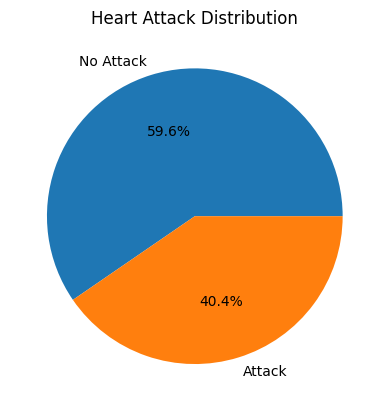

In [146]:
counts = data['heart_attack'].value_counts()

plt.pie(counts,labels=['No Attack', 'Attack'],autopct='%1.1f%%')

plt.title('Heart Attack Distribution')

plt.show()

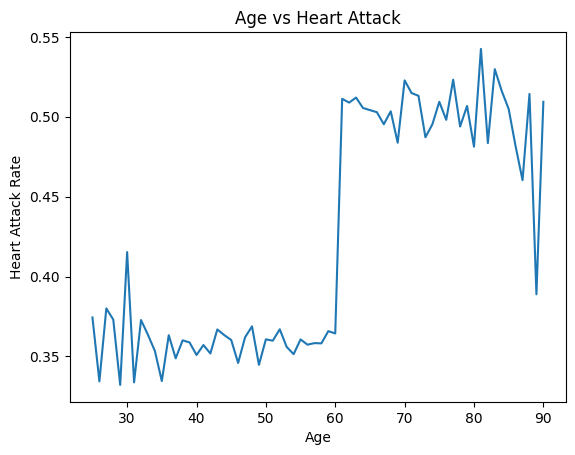

In [147]:
age_attack = data.groupby('age')['heart_attack'].mean()

plt.plot(age_attack.index,age_attack.values)

plt.xlabel('Age')

plt.ylabel('Heart Attack Rate')

plt.title('Age vs Heart Attack')

plt.show()

1) Below Age 60
    - about 35% attack rate
    - relatively lower risk

2) After Age 60
    - suddenly increases to around 50%

- As age increases, heart attack risk increases

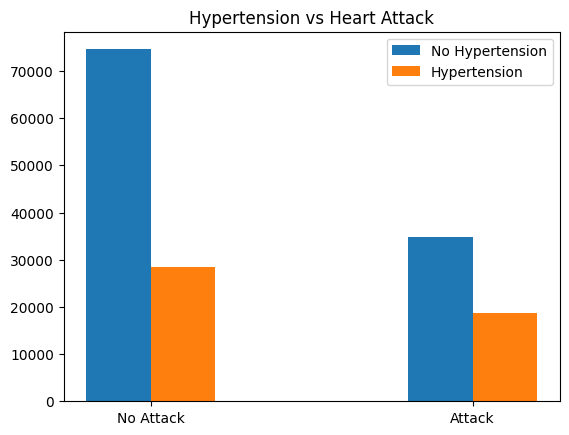

In [148]:
hypertension_0 = data[data['hypertension'] == 0]['heart_attack'].value_counts()
hypertension_1 = data[data['hypertension'] == 1]['heart_attack'].value_counts()
a= [0, 1]

plt.bar(a, hypertension_0, width=0.2, label='No Hypertension')
plt.bar([i + 0.2 for i in a], hypertension_1, width=0.2, label='Hypertension')
plt.xticks([0.1, 1.1], ['No Attack', 'Attack'])

plt.title('Hypertension vs Heart Attack')
plt.legend()

plt.show()

1. Most People Without Hypertension Had No Heart Attack

2. Even people without hypertension still had heart attacks.

3. People with hypertension are more likely to experience heart attacks.

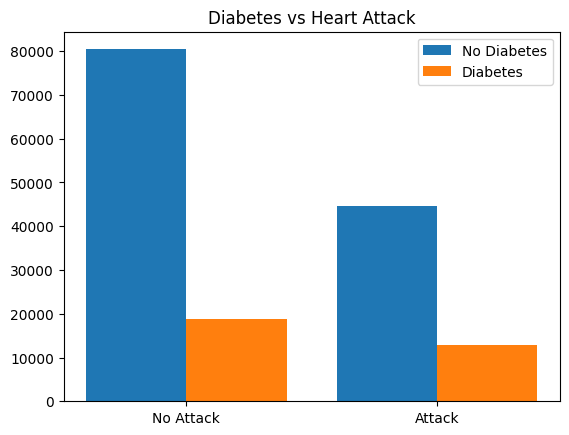

In [149]:
diabetes_0 = data[data['diabetes'] == 0]['heart_attack'].value_counts()

diabetes_1 = data[data['diabetes'] == 1]['heart_attack'].value_counts()

x = [0, 1]

plt.bar(x, diabetes_0, width=0.4, label='No Diabetes')

plt.bar([i + 0.4 for i in x], diabetes_1, width=0.4, label='Diabetes')

plt.xticks([0.2, 1.2], ['No Attack', 'Attack'])

plt.title('Diabetes vs Heart Attack')

plt.legend()

plt.show()

1. Most Non-Diabetic People Did Not Have Heart Attacks

2. Diabetes is an important risk factor, but not the only cause.

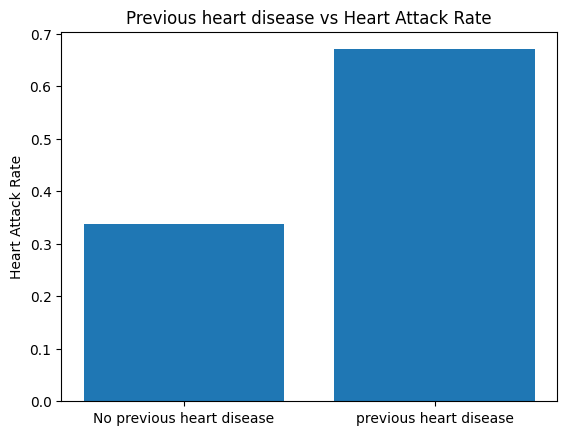

In [150]:
previous_heart_disease = data.groupby('previous_heart_disease')['heart_attack'].mean()

plt.bar(['No previous heart disease', 'previous heart disease'],previous_heart_disease)

plt.ylabel('Heart Attack Rate')

plt.title('Previous heart disease vs Heart Attack Rate')

plt.show()

1. There is a clear increase in the heart attack rate for individuals who have a history of heart disease.

2. Which is nearly double that of people without heart disease history

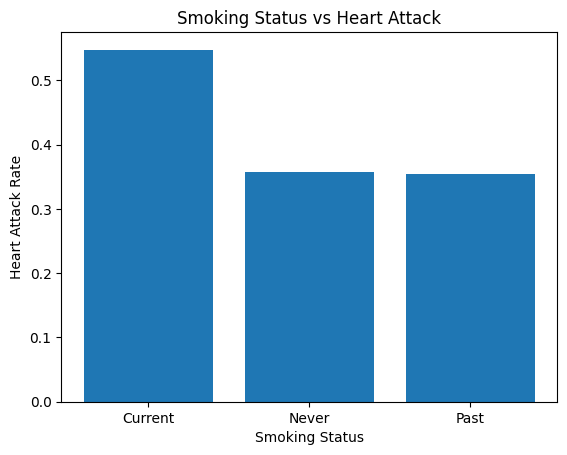

In [151]:
smoking_attack_rate = [

    data[data['smoking_status_Current'] == 1]['heart_attack'].mean(),

    data[data['smoking_status_Never'] == 1]['heart_attack'].mean(),

    data[data['smoking_status_Past'] == 1]['heart_attack'].mean()

]

labels = ['Current', 'Never', 'Past']

plt.bar(labels, smoking_attack_rate)

plt.xlabel('Smoking Status')

plt.ylabel('Heart Attack Rate')

plt.title('Smoking Status vs Heart Attack')

plt.show()

1. Current Smokers: Have the highest heart attack rate, at approximately 0.55.

2. Never Smokers and Past Smokers  Have a significantly lower rate.

In [152]:
corr = data.corr()

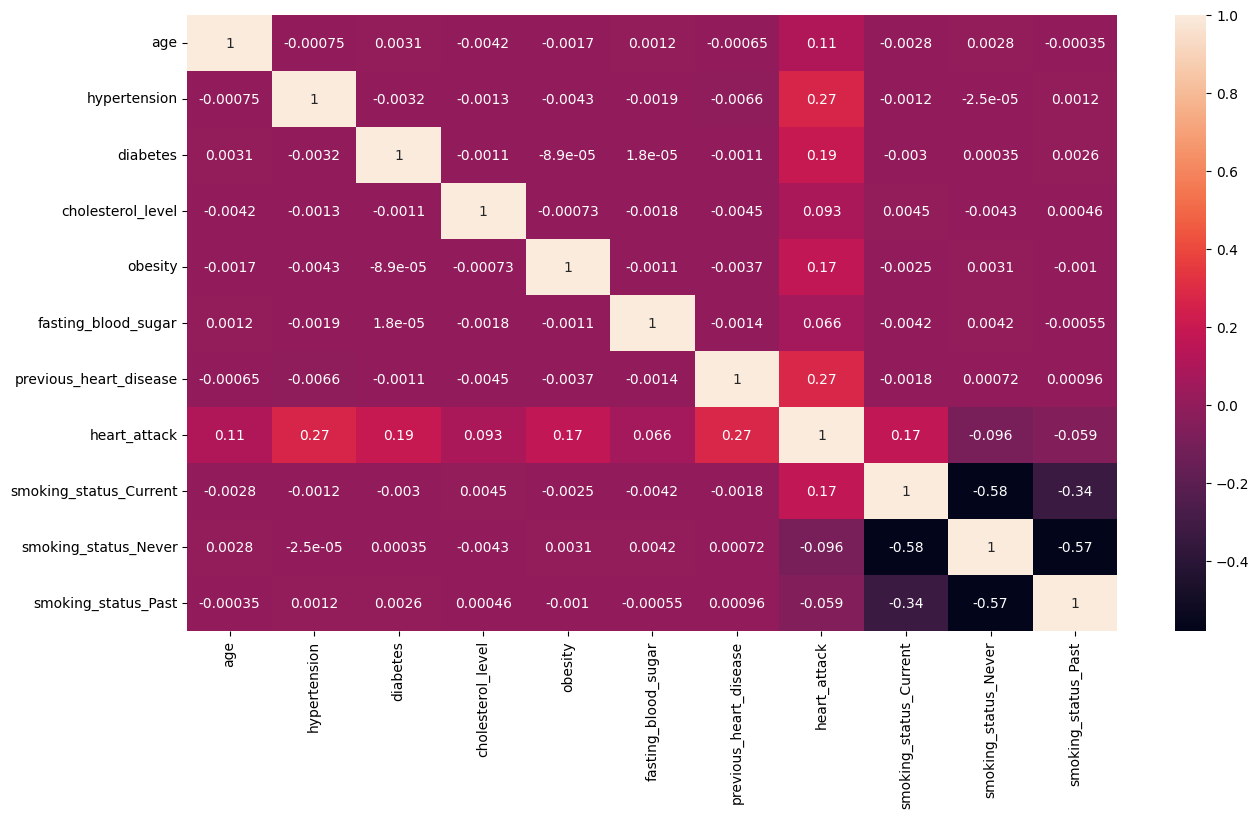

In [153]:
plt.figure(figsize=[15,8])
sns.heatmap(corr,annot=True)
plt.show()

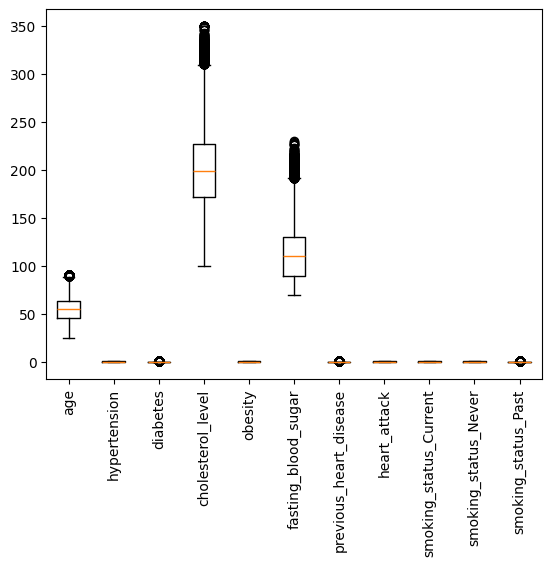

In [154]:
plt.boxplot(data)
plt.xticks([1,2,3,4,5,6,7,8,9,10,11],data.columns,rotation=90)
plt.show()

In [155]:
data.columns

Index(['age', 'hypertension', 'diabetes', 'cholesterol_level', 'obesity',
       'fasting_blood_sugar', 'previous_heart_disease', 'heart_attack',
       'smoking_status_Current', 'smoking_status_Never',
       'smoking_status_Past'],
      dtype='str')

In [156]:
# for i in data.columns:
#     plt.boxplot(data[i])
#     plt.title(i)
#     plt.show()

In [157]:
x = data.drop('heart_attack',axis=1)
x.shape

(156567, 10)

In [158]:
y= data['heart_attack']
y.shape

(156567,)

In [159]:
from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=.3,random_state=42)

In [160]:
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()

# x_train = scaler.fit_transform(x_train)
# x_test = scaler.transform(x_test)

Random Forest
-

In [161]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=150,criterion='gini')

rf.fit(x_train,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",150
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [162]:
y_pred = rf.predict(x_test)


In [163]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
test_acc = accuracy_score(y_test,y_pred)
test_acc

0.69964446147623

In [164]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.73      0.78      0.76     27995
           1       0.64      0.59      0.61     18976

    accuracy                           0.70     46971
   macro avg       0.69      0.68      0.68     46971
weighted avg       0.70      0.70      0.70     46971



In [165]:
y_train_pred = rf.predict(x_train)
train_acc = accuracy_score(y_train_pred,y_train)
train_acc


0.997408664549801

In [166]:
if accuracy_score(y_train,y_train_pred)<.60:
    print("underfit")

elif accuracy_score(y_train,y_train_pred) > accuracy_score(y_test,y_pred)+.10:
    print("overfit")

else:
    print("good fit")

overfit


In [167]:
from sklearn.neighbors import KNeighborsClassifier

In [168]:
knn = KNeighborsClassifier(n_neighbors =15)
knn.fit(x_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",15
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [169]:
# cls1 = KNeighborsClassifier()

In [170]:
# from sklearn.model_selection import GridSearchCV


# params = {'n_neighbors':[9,11,13,15],'weights' : ['uniform', 'distance'],'algorithm' : ['auto', 'ball_tree', 'kd_tree', 'brute'],'p' :[1,2]}

# clf = GridSearchCV(cls1,params,cv=10,scoring='accuracy')

In [171]:

# clf.fit(x_train,y_train)

In [172]:
# clf.best_params_

In [173]:
knn = KNeighborsClassifier(algorithm='auto',n_neighbors =15, p= 1, weights= 'uniform')
knn.fit(x_train,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",15
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",1
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [174]:
y_pred = knn.predict(x_test)

In [175]:
from sklearn.metrics import accuracy_score,classification_report,confusion_matrix
test_acc = accuracy_score(y_test,y_pred)
test_acc

0.6439292329309574

In [176]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.65      0.87      0.74     27995
           1       0.62      0.31      0.41     18976

    accuracy                           0.64     46971
   macro avg       0.63      0.59      0.58     46971
weighted avg       0.64      0.64      0.61     46971



In [177]:
y_train_pred = knn.predict(x_train)
train_acc = accuracy_score(y_train_pred,y_train)
train_acc


0.6943410343443192

In [178]:
if accuracy_score(y_train,y_train_pred)<.60:
    print("underfit")

elif accuracy_score(y_train,y_train_pred) > accuracy_score(y_test,y_pred)+.10:
    print("overfit")

else:
    print("good fit")

good fit


In [179]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(knn,x,y,cv=5)

print('CV scores :',cv_scores)
print('Mean CV Accuracy :',cv_scores.mean())
print('CV std accuracy :',cv_scores.std())

CV scores : [0.64574951 0.6497094  0.64535496 0.64417335 0.64155463]
Mean CV Accuracy : 0.6453083673943718
CV std accuracy : 0.002643659086067984


In [180]:
from sklearn.tree import DecisionTreeClassifier


dt = DecisionTreeClassifier(criterion='gini')
dt.fit(x_train,y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the curre

In [181]:
y_pred = dt.predict(x_test)

In [182]:
test_acc = accuracy_score(y_test,y_pred)
test_acc

0.6511251623342063

In [183]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.71      0.70      0.71     27995
           1       0.57      0.57      0.57     18976

    accuracy                           0.65     46971
   macro avg       0.64      0.64      0.64     46971
weighted avg       0.65      0.65      0.65     46971



In [184]:
y_train_pred = dt.predict(x_train)
train_acc = accuracy_score(y_train_pred,y_train)
train_acc

0.997408664549801

In [185]:
if accuracy_score(y_train,y_train_pred)<.60:
    print("underfit")

elif accuracy_score(y_train,y_train_pred) > accuracy_score(y_test,y_pred)+.10:
    print("overfit")

else:
    print("good fit")

overfit


In [186]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(dt,x,y,cv=5)

print('CV scores :',cv_scores)
print('Mean CV Accuracy :',cv_scores.mean())
print('CV std accuracy :',cv_scores.std())

CV scores : [0.65178514 0.65022035 0.64979402 0.65209338 0.65567017]
Mean CV Accuracy : 0.6519126113403841
CV std accuracy : 0.0020746260544748643


In [187]:
from sklearn.naive_bayes import GaussianNB
nb = GaussianNB()

nb.fit(x_train,y_train)

,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [188]:
y_pred = nb.predict(x_test)

In [189]:
test_acc = accuracy_score(y_test,y_pred)
test_acc

0.7180387898916353

In [190]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.77      0.76      0.76     27995
           1       0.65      0.66      0.65     18976

    accuracy                           0.72     46971
   macro avg       0.71      0.71      0.71     46971
weighted avg       0.72      0.72      0.72     46971



In [191]:
y_train_pred = nb.predict(x_train)
train_acc = accuracy_score(y_train_pred,y_train)
train_acc

0.7169695974305632

In [192]:
if accuracy_score(y_train,y_train_pred)<.60:
    print("underfit")

elif accuracy_score(y_train,y_train_pred) > accuracy_score(y_test,y_pred)+.10:
    print("overfit")

else:
    print("good fit")

good fit


In [193]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(nb,x,y,cv=5)

print('CV scores :',cv_scores)
print('Mean CV Accuracy :',cv_scores.mean())
print('CV std accuracy :',cv_scores.std())

CV scores : [0.71913521 0.71747461 0.7166672  0.72209625 0.71411235]
Mean CV Accuracy : 0.7178971250929449
CV std accuracy : 0.0026525950335786076


In [194]:
# from sklearn.linear_model import LogisticRegression
# from sklearn.model_selection import GridSearchCV


# tuning = LogisticRegression()
# params = {'C': [0.01, 0.1, 1, 10, 100],'solver': ['liblinear', 'saga'],'max_iter': [100, 500, 1000]}

# param = GridSearchCV(tuning,params,scoring='accuracy',cv=5)

# param.fit(x_train,y_train)

In [195]:
# param.best_params_

In [196]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [197]:
y_pred = lr.predict(x_test)


In [198]:
test_acc = accuracy_score(y_test,y_pred)
test_acc

0.7294287964914522

In [199]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.75      0.82      0.78     27995
           1       0.69      0.59      0.64     18976

    accuracy                           0.73     46971
   macro avg       0.72      0.71      0.71     46971
weighted avg       0.73      0.73      0.72     46971



In [200]:
y_train_pred = lr.predict(x_train)
train_acc = accuracy_score(y_train_pred,y_train)
train_acc

0.7283295010766816

In [201]:
if train_acc <.6 and test_acc<.6:
    print('Underfit')
elif train_acc > test_acc+.1:
    print('Overfit')
else:
    print('Good fit')


Good fit


In [202]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(lr,x,y,cv=5)

print('CV scores :',cv_scores)
print('Mean CV Accuracy :',cv_scores.mean())
print('CV std accuracy :',cv_scores.std())

CV scores : [0.72766175 0.72801303 0.7265353  0.7357647  0.72560917]
Mean CV Accuracy : 0.7287167906315074
CV std accuracy : 0.0036248467910299483


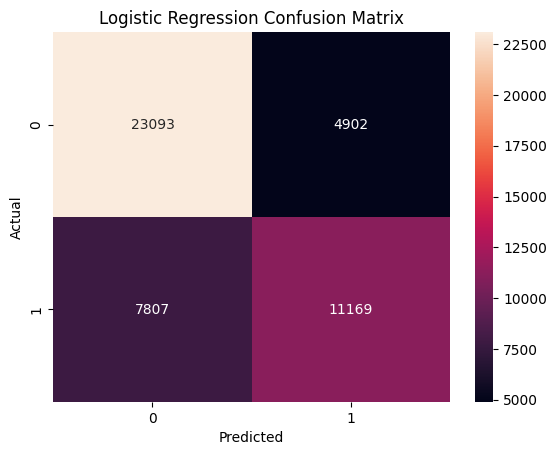

In [212]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [203]:
# High Mean + Low Std (<.05)  = Good model

In [207]:
x.info()

<class 'pandas.DataFrame'>
Index: 156567 entries, 0 to 158354
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   age                     156567 non-null  int64  
 1   hypertension            156567 non-null  int64  
 2   diabetes                156567 non-null  int64  
 3   cholesterol_level       156567 non-null  int64  
 4   obesity                 156567 non-null  int64  
 5   fasting_blood_sugar     156567 non-null  int64  
 6   previous_heart_disease  156567 non-null  int64  
 7   smoking_status_Current  156567 non-null  float64
 8   smoking_status_Never    156567 non-null  float64
 9   smoking_status_Past     156567 non-null  float64
dtypes: float64(3), int64(7)
memory usage: 13.1 MB


In [208]:
x.head()

,age,hypertension,diabetes,cholesterol_level,obesity,fasting_blood_sugar,previous_heart_disease,smoking_status_Current,smoking_status_Never,smoking_status_Past
0,60,0,1,211,0,173,0,0.0,1.0,0.0
1,53,0,0,208,0,70,1,0.0,0.0,1.0
2,62,0,0,231,1,118,0,0.0,0.0,1.0
3,73,1,0,202,0,98,0,0.0,1.0,0.0
4,52,1,0,232,0,104,1,1.0,0.0,0.0


In [209]:
data.head()

,age,hypertension,diabetes,cholesterol_level,obesity,fasting_blood_sugar,previous_heart_disease,heart_attack,smoking_status_Current,smoking_status_Never,smoking_status_Past
0,60,0,1,211,0,173,0,0,0.0,1.0,0.0
1,53,0,0,208,0,70,1,0,0.0,0.0,1.0
2,62,0,0,231,1,118,0,1,0.0,0.0,1.0
3,73,1,0,202,0,98,0,0,0.0,1.0,0.0
4,52,1,0,232,0,104,1,1,1.0,0.0,0.0


In [210]:
import pickle

pickle.dump(lr,open('model.sav','wb'))
pickle.dump(ohe_smoking,open('ohe_smoking.sav','wb'))
# pickle.dump(scaler,open('scaler.sav','wb'))
